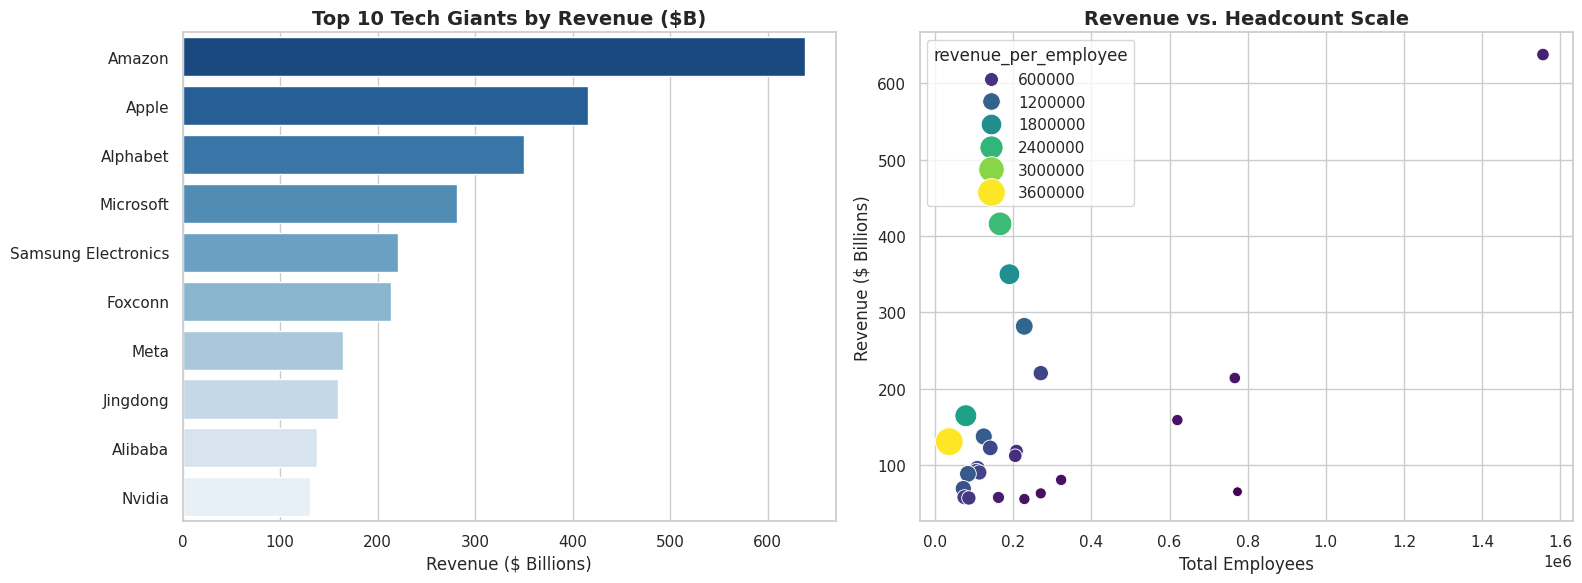

--- SUMMARY STATS ---
Top Performer: Amazon ($637.9B)


In [5]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# 1. SCRAPE DATA WITH BROWSER HEADERS
url = (
    "https://en.wikipedia.org/wiki/List_of_largest_technology_companies_by_revenue"
)
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    )
}

response = requests.get(url, headers=headers)

# Wrapped response in io.StringIO to resolve Pandas deprecation warning
tables = pd.read_html(io.StringIO(response.text))

# Find the specific table containing company revenue data
df = None
for t in tables:
  if isinstance(t.columns, pd.MultiIndex):
    t.columns = [" ".join(col).strip() for col in t.columns.values]

  col_string = " ".join([str(c) for c in t.columns]).lower()
  if "company" in col_string and "revenue" in col_string:
    df = t.copy()
    break

if df is None:
  df = tables[0]

# Clean reference tags from column titles
df.columns = [str(c).split("[")[0].strip() for c in df.columns]

# Dynamically map columns by keyword matching
comp_col = [
    c for c in df.columns if "company" in c.lower() or "name" in c.lower()
][0]
rev_col = [c for c in df.columns if "revenue" in c.lower()][0]
emp_col = [
    c
    for c in df.columns
    if "employee" in c.lower() or "headcount" in c.lower()
][0]

df = df.rename(
    columns={
        comp_col: "company",
        rev_col: "revenue_billions",
        emp_col: "employees",
    }
)

# 2. DATA CLEANING & FEATURE ENGINEERING
df["revenue_billions"] = pd.to_numeric(
    df["revenue_billions"].astype(str).str.replace(r"[^\d.]", "", regex=True),
    errors="coerce",
)
df["employees"] = pd.to_numeric(
    df["employees"].astype(str).str.replace(r"[^\d.]", "", regex=True),
    errors="coerce",
)

df = df.dropna(subset=["company", "revenue_billions", "employees"]).reset_index(
    drop=True
)
df["revenue_per_employee"] = (df["revenue_billions"] * 1e9) / df["employees"]

# 3. VISUALIZATION
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 10 by Revenue (Updated syntax: hue='company', legend=False)
top_10 = df.sort_values(by="revenue_billions", ascending=False).head(10)
sns.barplot(
    ax=axes[0],
    data=top_10,
    x="revenue_billions",
    y="company",
    hue="company",
    palette="Blues_r",
    legend=False,
)
axes[0].set_title(
    "Top 10 Tech Giants by Revenue ($B)", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("Revenue ($ Billions)")
axes[0].set_ylabel("")

# Plot 2: Revenue vs. Headcount Efficiency
sns.scatterplot(
    ax=axes[1],
    data=df,
    x="employees",
    y="revenue_billions",
    size="revenue_per_employee",
    sizes=(50, 400),
    hue="revenue_per_employee",
    palette="viridis",
)
axes[1].set_title(
    "Revenue vs. Headcount Scale", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel("Total Employees")
axes[1].set_ylabel("Revenue ($ Billions)")

plt.tight_layout()
plt.show()

print("--- SUMMARY STATS ---")
print(
    f"Top Performer: {df.iloc[0]['company']} (${df.iloc[0]['revenue_billions']}B)"
)